Thuật toán hội tụ tại vòng lặp:203


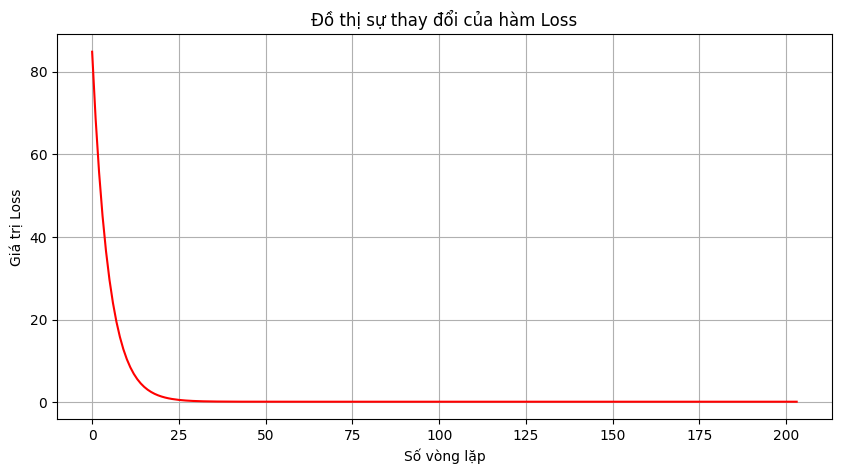

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class LinearRegression:
  def __init__(self, lr: float=0.01, n_iters:int=1000, tol: float = 1e-7) -> None:
    self.lr=lr
    self.n_iters=n_iters
    self.tol=tol
    self.weights=None
    self.bias=None
    self.loss_history=[]
  def fit(self, X, y):
    #Bước 1: Khởi tạo tham số
    num_samples, num_features=X.shape
    self.weights=np.zeros(num_features)
    self.bias=0
    for i in range (self.n_iters):
      #Bước 2: Dự đoán đầu ra
      y_pred=np.dot(X, self.weights)+self.bias
      #Bước 3: Đánh giá sai số
      loss = (1/(2*num_samples))*np.sum((y_pred-y)**2)
      self.loss_history.append(loss)
      #Bước 4:  Tính Gradient Descent
      dw=(1/num_samples)*np.dot(X.T, (y_pred-y))
      db=(1/num_samples)*np.sum(y_pred-y)
      #Bước 5: Cập nhật tham số
      self.weights=self.weights-self.lr*dw
      self.bias = self.bias-self.lr*db
      #Bước 6: Kiểm tra điều kiện dừng
      if i>0 and abs(self.loss_history[i]-self.loss_history[i-1])<self.tol:
        print(f"Thuật toán hội tụ tại vòng lặp:{i}")
        break
    return self
  def predict(self,X):
    return np.dot(X, self.weights)+self.bias

#Đọc dữ liệu
df=pd.read_csv('wine.csv')
y=df['Alcohol'].values
X=df.drop(columns=['Wine','Alcohol']).values
X_scaled=(X-np.mean(X, axis=0))/np.std(X, axis=0)
model = LinearRegression(lr=0.1, n_iters=1000)
model.fit(X_scaled, y)

plt.figure(figsize=(10, 5))
plt.plot(model.loss_history, color='red')
plt.title('Đồ thị sự thay đổi của hàm Loss')
plt.xlabel('Số vòng lặp')
plt.ylabel('Giá trị Loss')
plt.grid(True)
plt.show()